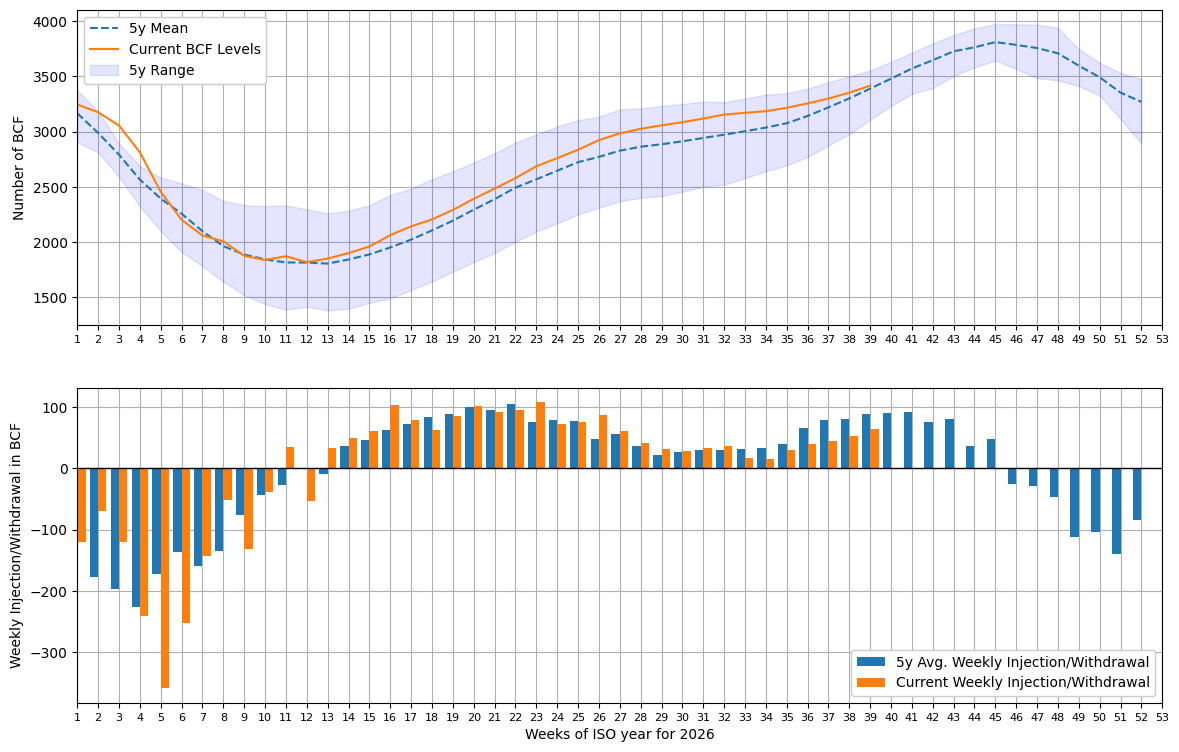

In [14]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from datetime import date #we use datetime because unlike yfinance, EIA and other API's don't automatically convert the dates


API_KEY = "K1kHaYDyYlIRtPWWOTMA8JBkIUjX2Vsgx7yUDSUP"
url = "https://api.eia.gov/v2/natural-gas/stor/wkly/data/?"


#get it to where its last 5 years no matter current
#make it to where we can make sure its only current year
current_year = date.today().year
past_five = list(range(current_year - 5, current_year))

#get data from api key
parameters = {"api_key" : API_KEY,
              "frequency" : "weekly",
              "data[0]" : "value",
              "facets[series][]" : "NW2_EPG0_SWO_R48_BCF",
              "start" : f"{current_year - 6}-01-01"
             }


#-----------------Preparing our data
response = requests.get(url, params=parameters)
data = response.json()["response"]["data"] 


df=pd.DataFrame(data)
df=df[["period", "value"]] #


df["period"] = pd.to_datetime(df["period"])
df["value"] = df["value"].astype(float)

#sometimes data is messy so this ensures our time series is in order
df = df.sort_values("period")

df["weekly change"] = df["value"].diff()

df["year"] = df["period"].dt.isocalendar().year
df["week"] = df["period"].dt.isocalendar().week

#Create a pivot table to make it easier to graph
BCF_levels = df.pivot_table(index= "week", columns = "year",values = "value")

change = df.pivot_table(index = "week", columns = "year", values = "weekly change")

#------------------ Getting Ready to Plot
#get 5 year mean and current levels ready to plot
fivey_mean = BCF_levels[past_five].mean(axis=1)
current_BCF_levels = BCF_levels[current_year]

#min and max for range on chart
fivey_min = BCF_levels[past_five].min(axis=1)
fivey_max = BCF_levels[past_five].max(axis=1)


#5 year injection avg and current weekly injections
weekly_inj_avg = change[past_five].mean(axis=1)
current_change = change[current_year]


#prepare charts 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (14, 9), sharex=True)

#---------------------------- Plotting the Data
#ploting 5 year mean
ax1.plot(fivey_mean, linestyle = ("--"), label = "5y Mean")
#plotting current levels against 5 year mean
ax1.plot(current_BCF_levels, linestyle = ("-"), label = "Current BCF Levels")
#labeling ax1
ax1.tick_params(labelbottom = True)
#plotting 5 year range
ax1.fill_between(fivey_mean.index, fivey_min, fivey_max, 
                 color = "blue", alpha = 0.1, label = "5y Range")
#ax1 legend and y label
ax1.legend(loc = "upper left", framealpha = 1)
ax1.set_ylabel("Number of BCF")

#plotting weekly injections against 5y avg
ax2.bar(change.index - 0.2, weekly_inj_avg, width = 0.4, label = "5y Avg. Weekly Injection/Withdrawal")
ax2.bar(change.index + 0.2, current_change, width = 0.4, label = "Current Weekly Injection/Withdrawal")
ax2.set_xlabel(f"Weeks of ISO year for {current_year}")
ax2.set_ylabel("Weekly Injection/Withdrawal in BCF")

#legend for ax2
ax2.legend(loc = "lower right", framealpha = 1)

# y = 0 to better see injections
y = 0
ax2.axhline(y, color = "black", linewidth = 1)

#setting the x axis so it matches the start and end
for ax in (ax1, ax2):
    ax.set_xlim (1, 53)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.set_axisbelow(True)

#adjust
ax1.tick_params(axis = 'x', labelsize = 8)
ax2.tick_params(axis = 'x', labelsize = 8)

ax1.grid()
ax2.grid()
plt.show()



